# Distributional Regression Benchmark

This notebook benchmarks fit and prediction performance of `DistributionalRegressionPDF` as the number of observations and the number of regressors increase. The benchmark intentionally uses a stable configuration (`x_interaction_order=1`) so that size effects remain interpretable rather than being dominated by a combinatorial basis explosion.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from distributional_regression_pdf import DistributionalRegressionPDF

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(20260420)


In [2]:
def simulate_data(n_samples, n_features, seed):
    local_rng = np.random.default_rng(seed)
    X = local_rng.normal(size=(n_samples, n_features))
    base = 0.50 * np.sin(X[:, 0])
    if n_features > 1:
        base -= 0.20 * X[:, 1]
    if n_features > 2:
        base += 0.10 * X[:, 2] * X[:, 0]
    sigma_driver = 0.30 + 0.05 * np.abs(X[:, 0])
    if n_features > 1:
        sigma_driver += 0.03 * np.abs(X[:, 1])
    tail = local_rng.lognormal(mean=0.15 * X[:, 0], sigma=sigma_driver)
    y = base + tail
    return y, X


def run_case(n_samples, n_features, degree_y=4, degree_x=2, nodes=48):
    y, X = simulate_data(n_samples, n_features, seed=1000 + 10 * n_samples + n_features)
    model = DistributionalRegressionPDF(
        degree_y=degree_y,
        degree_x=degree_x,
        include_interactions=True,
        x_interaction_order=1,
        n_integration_nodes=nodes,
    )

    start = time.perf_counter()
    model.fit(y, X, l1_alpha=1e-4, l2_alpha=1e-3, cv=False)
    fit_seconds = time.perf_counter() - start

    probe_y = np.linspace(np.quantile(y, 0.1), np.quantile(y, 0.9), 128)
    start = time.perf_counter()
    _ = model.pdf(probe_y, X[0])
    pred_seconds = time.perf_counter() - start

    return {
        'n_samples': n_samples,
        'n_features': n_features,
        'fit_seconds': fit_seconds,
        'pdf_eval_seconds': pred_seconds,
        'n_parameters': model.n_parameters_,
        'mean_loglik': model.fit_diagnostics_['mean_loglik'],
        'optimizer_success': model.optimizer_result_['success'],
    }


In [3]:
sample_sizes = [200, 500, 1000, 2000]
feature_counts = [2, 5, 10, 20]

records = []
for n_samples in sample_sizes:
    for n_features in feature_counts:
        result = run_case(n_samples=n_samples, n_features=n_features)
        records.append(result)
        print(result)

results = pd.DataFrame(records)
results


{'n_samples': 200, 'n_features': 2, 'fit_seconds': 0.01739158295094967, 'pdf_eval_seconds': 0.00024233304429799318, 'n_parameters': 20, 'mean_loglik': -0.5204286546217722, 'optimizer_success': True}
{'n_samples': 200, 'n_features': 5, 'fit_seconds': 0.010338207939639688, 'pdf_eval_seconds': 0.00018974998965859413, 'n_parameters': 44, 'mean_loglik': -0.41542772608854867, 'optimizer_success': True}
{'n_samples': 200, 'n_features': 10, 'fit_seconds': 0.012204666039906442, 'pdf_eval_seconds': 0.00016350008081644773, 'n_parameters': 84, 'mean_loglik': -0.4363067296823291, 'optimizer_success': True}
{'n_samples': 200, 'n_features': 20, 'fit_seconds': 0.020557833020575345, 'pdf_eval_seconds': 0.0001982920803129673, 'n_parameters': 164, 'mean_loglik': -0.2177720074388317, 'optimizer_success': True}
{'n_samples': 500, 'n_features': 2, 'fit_seconds': 0.011087040998972952, 'pdf_eval_seconds': 0.00012758292723447084, 'n_parameters': 20, 'mean_loglik': -0.5357455919619327, 'optimizer_success': True

,n_samples,n_features,fit_seconds,pdf_eval_seconds,n_parameters,mean_loglik,optimizer_success
0,200,2,0.017392,0.000242,20,-0.520429,True
1,200,5,0.010338,0.000190,44,-0.415428,True
2,200,10,0.012205,0.000164,84,-0.436307,True
3,200,20,0.020558,0.000198,164,-0.217772,True
4,500,2,0.011087,0.000128,20,-0.535746,True
5,500,5,0.012582,0.000134,44,-0.461991,True
6,500,10,0.014828,0.000199,84,-0.530926,True
7,500,20,0.028246,0.000185,164,-0.355604,True
8,1000,2,0.012694,0.000105,20,-0.516269,True
9,1000,5,0.023729,0.000158,44,-0.512234,True


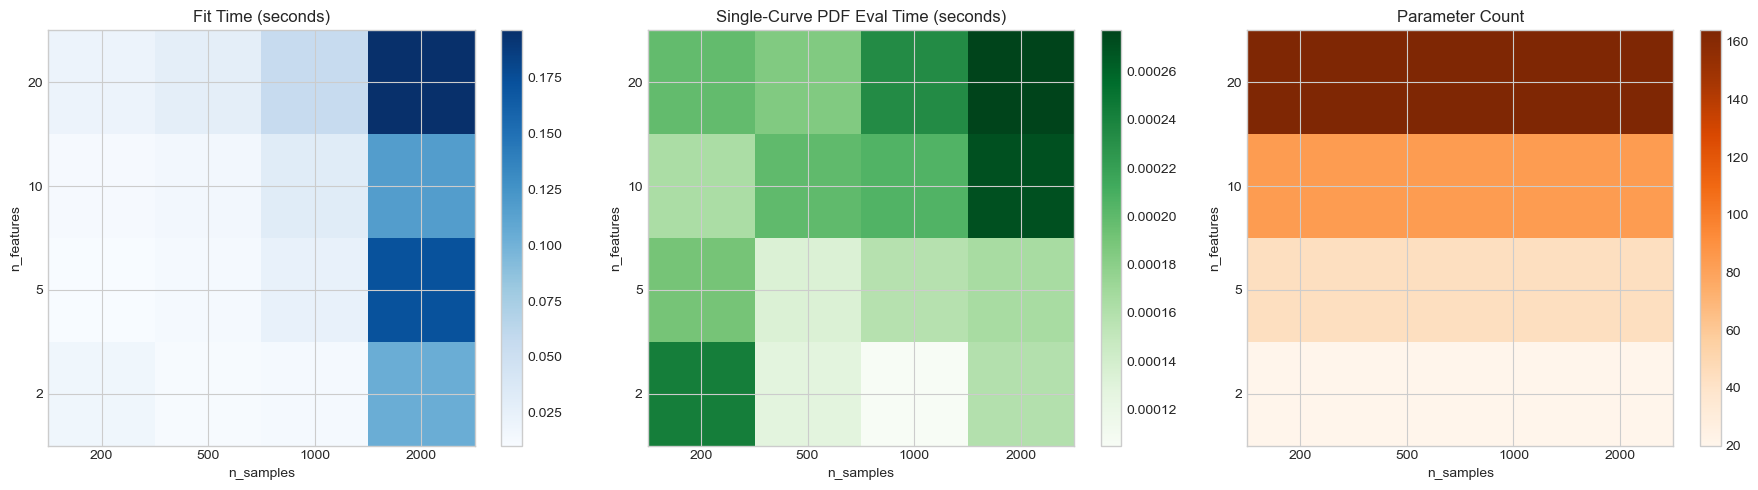

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fit_pivot = results.pivot(index='n_features', columns='n_samples', values='fit_seconds')
im0 = axes[0].imshow(fit_pivot.values, aspect='auto', origin='lower', cmap='Blues')
axes[0].set_title('Fit Time (seconds)')
axes[0].set_xlabel('n_samples')
axes[0].set_ylabel('n_features')
axes[0].set_xticks(range(len(fit_pivot.columns)), fit_pivot.columns)
axes[0].set_yticks(range(len(fit_pivot.index)), fit_pivot.index)
fig.colorbar(im0, ax=axes[0])

pred_pivot = results.pivot(index='n_features', columns='n_samples', values='pdf_eval_seconds')
im1 = axes[1].imshow(pred_pivot.values, aspect='auto', origin='lower', cmap='Greens')
axes[1].set_title('Single-Curve PDF Eval Time (seconds)')
axes[1].set_xlabel('n_samples')
axes[1].set_ylabel('n_features')
axes[1].set_xticks(range(len(pred_pivot.columns)), pred_pivot.columns)
axes[1].set_yticks(range(len(pred_pivot.index)), pred_pivot.index)
fig.colorbar(im1, ax=axes[1])

param_pivot = results.pivot(index='n_features', columns='n_samples', values='n_parameters')
im2 = axes[2].imshow(param_pivot.values, aspect='auto', origin='lower', cmap='Oranges')
axes[2].set_title('Parameter Count')
axes[2].set_xlabel('n_samples')
axes[2].set_ylabel('n_features')
axes[2].set_xticks(range(len(param_pivot.columns)), param_pivot.columns)
axes[2].set_yticks(range(len(param_pivot.index)), param_pivot.index)
fig.colorbar(im2, ax=axes[2])

fig.tight_layout()


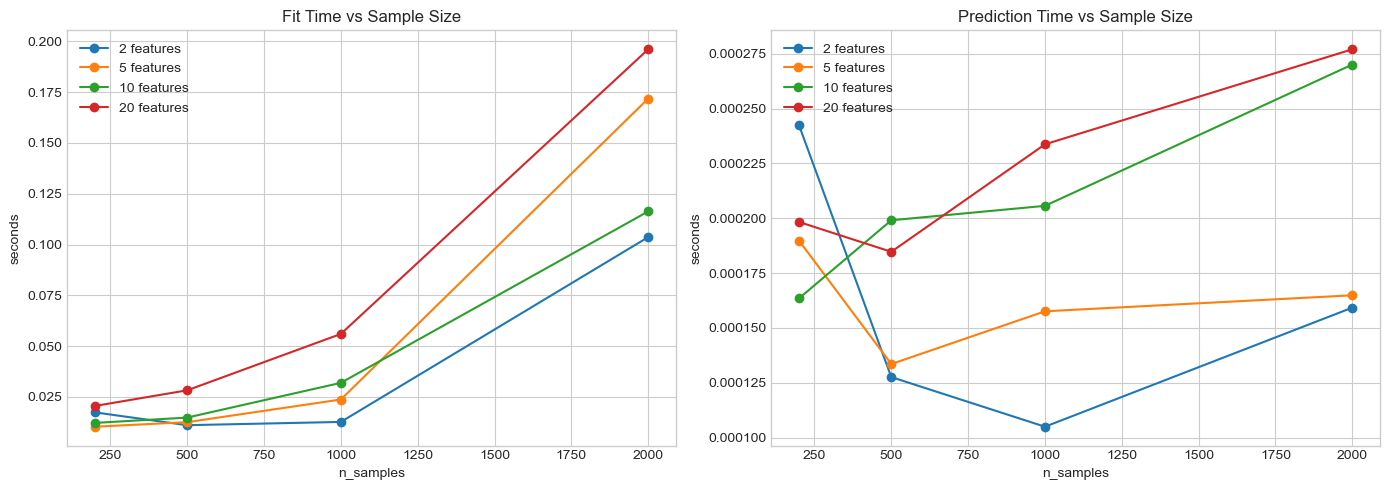

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n_features, subdf in results.groupby('n_features'):
    axes[0].plot(subdf['n_samples'], subdf['fit_seconds'], marker='o', label=f'{n_features} features')
    axes[1].plot(subdf['n_samples'], subdf['pdf_eval_seconds'], marker='o', label=f'{n_features} features')

axes[0].set_title('Fit Time vs Sample Size')
axes[0].set_xlabel('n_samples')
axes[0].set_ylabel('seconds')
axes[0].legend()

axes[1].set_title('Prediction Time vs Sample Size')
axes[1].set_xlabel('n_samples')
axes[1].set_ylabel('seconds')
axes[1].legend()

fig.tight_layout()


In [ ]:
results.sort_values(['n_features', 'n_samples']).reset_index(drop=True)
